This code has been prouced as a teaching resource for the UKSA space software, data and AI course run by the Space South Central Universities.

Contributors to this code includes: O. Umeh; B. Canning; A. Tolley

---

### Learning Outcome
<div class="alert alert-block alert-info"> 
<b>NOTE</b> In this notebook we will learn how to match OpenStreetMap and Satellite data then prepare it for an ML process.
</div>

---

### Standard Package Imports

In [94]:
# For interacting with the operating system (e.g., managing file paths)
import os

# Glob will let us handle our file structure on our computer for importing the files we have saved 
import glob

# For efficient numerical operations and array handling
import numpy as np

# For plotting, data visualization, and image manipulation
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# For downloading and analyzing OpenStreetMap (OSM) street networks
import osmnx as ox

# For encoding and decoding data in GeoJSON format
import geojson
import json

# For working with and manipulating geospatial data
import geopandas as gpd

# For making HTTP requests to web APIs
import requests

# This is the earthengine-api package - we will import our satelite data by querying google earth engine
import ee

# This package will enable us to work efficeintly with gridded raster datasets and vector datasets (important for GIS data type conversions) 
import rasterio
from rasterio.features import rasterize
from rasterio.windows import Window

# I'm going to filter my regions with a box shape below - you could do other things...
from shapely.geometry import box

# The below are some extras that could help us with plotting and other tasks - we won't specifically use these in the examples
# but you might want to explore some of their options yourself going through the exercises 
# import geemap.foliumap as emap # this imports a method of creating interactive maps with geemap
from pyproj import Geod # pyproj helps us work with coordinate transformations and projections (below instead we use geopandas .crs and .cx)

# This one because I only want to see errors not warnings - lazyness that you don't wan ot include when developing 
import logging
logging.getLogger('rasterio').setLevel(logging.ERROR)

---

### Preamble

In Casestudy Part 1 we picked Marrakech, Morocco as an area to invesigate pre- and post- earthquake.

In this part we have changed location to Indonesia will investigate the damage caused by an earth in 2018. We made this change because the damage is clearer in Sentinel-2 10m resolution images, which helps with your debugging when visualising some of the images.

#### Earthquake Information
There was a 7.5 magnitude earthquake that struck Indonesia on 28 September, 2018.  This quake was very destructive and accompanied by a tsunami, it caused buildings to collapse, landslides and flooding.  For context a summary from ESA can be found here: https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-2/Sentinel-2_maps_Indonesia_earthquake

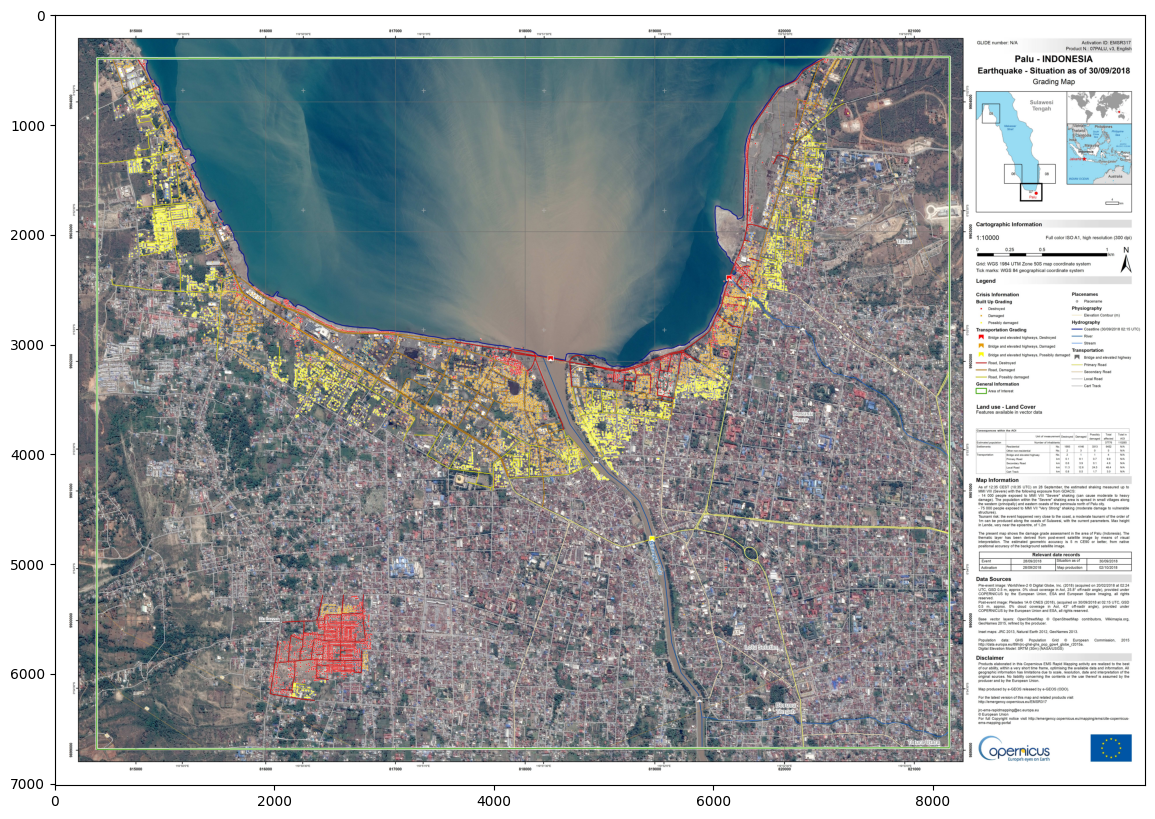

In [95]:
plt.figure(figsize=(20,10))
plt.imshow(Image.open("Copernicus_grading_map.jpg"));

**Our Aims**:
- Prepare OSM and Sentinel-2 Data for further use in a Machine Learning (ML) Computer Vision (CV) pipeline

In Part 1 we managed to:
1. Download required data (Recall using the `request` package)
2. Save data in a format we want (Recall using `os` and `glob` package)
3. Read in data (Recall using `rasterio` and `glob`)

In this part we will also learn to:

4. Combine spatial data to create building masks on the same coordinate reference system (Recall using `geopandas`)
5. Augment the data for generality (multiple ways to do this, can write you own code easily enough but remember that the packages like `PyTorch` or `Tensorflow` also come with fairly quick, speed optimised solutions)

---

#### Let's continue the project

First: define the area of interest

<div class="alert alert-block alert-warning">
See our EarthEngineAPI.ipynb for other examples of defining places of interest.
</div>

In [96]:
place_name = "Palu, Indonesia"
area_of_interest = ox.geocode_to_gdf(place_name)

Use OSM to identify the place and return a list of tagged 'buildings'

In [97]:
buildings = ox.features_from_place(place_name, tags={"building": True})

Make test plots: plot the bounding box of this place name and the buildings.

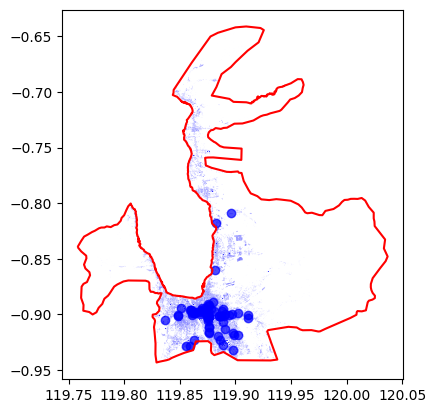

In [98]:
fig, ax = plt.subplots()
area_of_interest.boundary.plot(ax=ax, color="red")
buildings.plot(ax=ax, color="blue", alpha=0.7)
plt.show()

We will focus on the city of Palu - the region with the high density of buildings to the bottom of the figure above.

There are two reasons we choose Palu:
1. We are training a building classifier, we need plenty of examples of buildings to train and test our model
2. The entire region is too large for us to query all at once

<div class="alert alert-block alert-success"> 
 <strong>Exercises</strong>
 <br>
 <li> don't take my word for it - test this out! </li>
 <li> What happens when you enlarge the region of interest? What errors does the code produce? How might you deal with these errors? </li>
</div>

---

Define a polygon and filter only the buldings in this region.

We can do this using the `box` function imported from the `shapely` package.

<div class="alert alert-block alert-warning">
See `geopandas_examples.ipynb` for other examples of filtering geospatial datasets.
</div>

In [99]:
polygon = box(119.81, -0.95, 119.93, -0.86)
poly_gdf = gpd.GeoDataFrame([1], geometry=[polygon], crs=buildings.crs)

Plot the box onto the region to see where we have selected

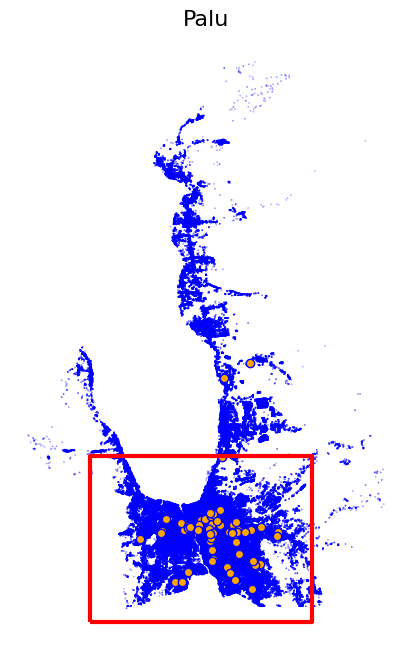

In [100]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
buildings.plot(ax=ax, color='orange', edgecolor='blue', linewidth=1)
poly_gdf.boundary.plot(ax=ax, color="red", linewidth=3)
ax.set_title("Palu", fontsize=16)
ax.set_axis_off() # remove the latitude-longitude axis ticks
plt.show()


This region captures Palu well, there are many online tools to draw regions by eye and extract bounding boxes: https://geojson.io/

---

Let's now filter to only grab buildings in this box.

In [101]:
buildings_filtered = buildings.cx[polygon.bounds[0]:polygon.bounds[2], polygon.bounds[1]:polygon.bounds[3]]

Plot again - remember to test your code frequently!

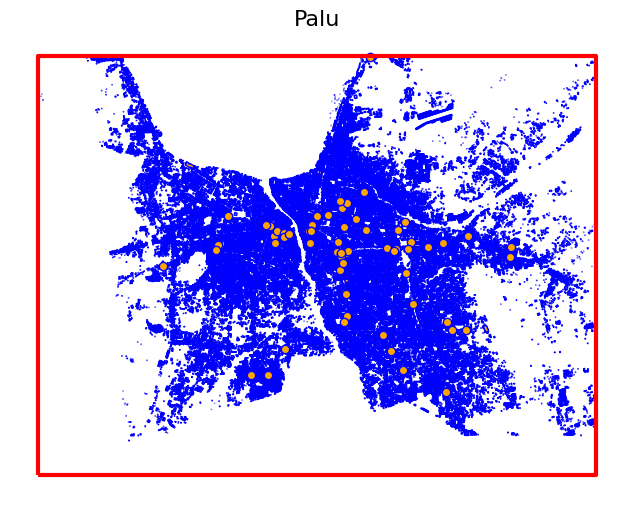

In [102]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
buildings_filtered.plot(ax=ax, color='orange', edgecolor='blue', linewidth=1)
poly_gdf.boundary.plot(ax=ax, color="red", linewidth=3)
ax.set_title("Palu", fontsize=16)
ax.set_axis_off()
plt.show()

We can save out these buildings to a `geojson` file

In [103]:
buildings.to_file("palu_buildings.geojson", driver="GeoJSON")

Let's explore the properties of this 'buildings' geodataframe, for example, check the total number of buildings

In [104]:
buildings=buildings_filtered[['geometry']]
print(f'There are {len(buildings)} buildings in Palu')

There are 99264 buildings in Palu


---

**Important**

We need to make sure all images and dataframes are in the same coordinate system.

Let's work out what coordinate reference system our buildings data is in at the moment.

<div class="alert alert-block alert-warning">
See our `geopandas_examples.ipynb` for examples of querying and changing coordinate reference frames.
</div>

In [105]:
buildings.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

---

### Download Sentinel-2 data for our region

Having chosen our region, downloaded our 'label' dataset from OpenStreetMap and refined our region, we are now ready to get Sentinel-2 data for this region.

<div class="alert alert-block alert-success">
 <strong>Exercises</strong>
 <br>
 <li> Why did we start with OpenStreetMap data and not the satellite data - why?</li>
</div>

We will download the data using the Google Earth Engine API.

Remember our steps from `EarthEngineAPI.ipynb`:
1. Authenticate yourself
2. Define your request
3. Make a http request with `requests`
4. Save data and load in with `rasterio`


In [106]:
ee.Authenticate()
ee.Initialize(project="uksa-training-course-materials") # copy your credentials here

Define the path where we will store the data. 

In [107]:
# If on the JupyterHub, uncomment the next line
# path='/home/jovyan/casestudy_data/'

# If on your own machine, uncomment the next line
path = './casestudy_data/'
# This will create a new directory in the same folder this notebook exists in

# Create a new directory if one doesn't already exist
os.makedirs(path, exist_ok=True)
print("Created directory!")

Created directory!


Reproduce the polygon bounds which defined our region of interest (roi) above in the format which Earth Engine requires.

Remember: most APIs use their own format.
Visit their help files for a description of their format is. 

In [108]:
roi = ee.Geometry.BBox(polygon.bounds[0], polygon.bounds[1], polygon.bounds[2], polygon.bounds[3])

We also need to define:

* Timescale of interest
* Satellite collection (see `EarthEngineAPI.ipynb` for how to find the right collection)
* Bands of interest
* What to do when there are multiple images - just select one? a mosaic or composite?
* Reject 'bad' quality data - Define 'quality' (e.g. cloudy)? Define 'bad' (e.g. percentage of cloud cover?)?

Consider the issues facing you with regard to timescale around the 'event' - what about season changes in the landscape - what is important to your use case?

---

### Define Google Earth Engine Parameters

Timescale: We need images before and after 28th September 2018

Bands of interest: Optical - Red, Green, Blue

Multiple Images: Create a mosaic

Satellite collection: Sentinel-2

Quality: Reject images with greater than 10\% cloud cover

Pre-earthquake Images

In [109]:
start_date = '2018-07-01'
end_date = '2018-09-27'
satellite_collection = 'COPERNICUS/S2_HARMONIZED'
cloud_percentage = 10


# Define the Sentinel-2 image collection and filter by date and region
collection = ee.ImageCollection(satellite_collection) \
    .filterDate(start_date, end_date) \
    .filterBounds(roi) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_percentage))  # Filter images with less than 10% cloud cover

# Get the first image from the collection use .first()
# Get the maximum pixels for a composite - google EE definition use .max()
# Get a mosaic of the images - google EE definition use .mosaic()
# Check the documentation for all the transformations you can do

#image = collection.first()
#image = collection.max()
image = collection.mosaic()

# Select the desired bands (e.g., B4: Red, B3: Green, B2: Blue for RGB)
image_rgb = image.select(['B4', 'B3', 'B2'])

# Export the image to Google Drive or as a URL
url = image_rgb.getDownloadURL({
    'scale': 10,           # Set the resolution (in meters)
    'region': roi,         # Region of interest to download
    'format': 'GEO_TIFF'
})

Download the satellite image using the `requests` package

Save the image to our casestudy data directory

In [110]:
response = requests.get(url)

file_path = path + 'pre_sentinel.tif'
with open(file_path, 'wb') as fd:
    fd.write(response.content)

Use `glob` to check the file has been downloaded

In [111]:
glob.glob(path+'*')

['./casestudy_data/output_annotations',
 './casestudy_data/pre_sentinel.tif',
 './casestudy_data/yolo_dataset',
 './casestudy_data/pre_earthquake_tiles',
 './casestudy_data/masks',
 './casestudy_data/post_sentinel.tif']

Repeat for the post-earthquake image.

We only need to change the date range however,  you can adjust other parameters to get a better image or any image. Post-flood or volcano eruption there might not be many cloudless images so we need to allow a greater \% of cloud cover.

In [112]:
start_date = '2018-09-28'
end_date = '2018-10-28'
satellite_collection = 'COPERNICUS/S2_HARMONIZED'
cloud_percentage = 15

collection = ee.ImageCollection(satellite_collection) \
    .filterDate(start_date, end_date) \
    .filterBounds(roi) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_percentage))

#image = collection.first()
#image = collection.max()
image = collection.mosaic()

image_rgb = image.select(['B4', 'B3', 'B2'])

url = image_rgb.getDownloadURL({
    'scale': 10,
    'region': roi,
    'format': 'GEO_TIFF'
})

Download the image and check the directory, we should now have a pre- and post- earthquake set of images.

In [113]:
response = requests.get(url)

file_path = path + 'post_sentinel.tif'
with open(file_path, 'wb') as fd:
    fd.write(response.content)

glob.glob(path+'*')

['./casestudy_data/output_annotations',
 './casestudy_data/pre_sentinel.tif',
 './casestudy_data/yolo_dataset',
 './casestudy_data/pre_earthquake_tiles',
 './casestudy_data/masks',
 './casestudy_data/post_sentinel.tif']

---

Now we have these images we can plot and check them.

We can also check the coordinate reference system now to see if it is consistent with the OSM data.

We are reading the image in using the `rasterio` package and plotting using `matplotlib`

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0716..2.089].


EPSG:4326


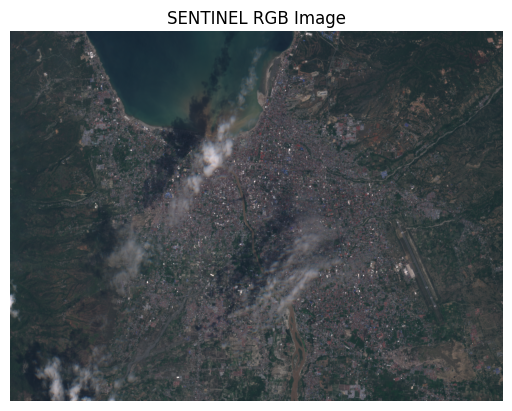

In [114]:
with rasterio.open(path + 'post_sentinel.tif') as src:
    sentinel_image = src.read([1, 2, 3])  # Read the Red, Green, Blue bands
    out_transform = src.transform
    print(src.crs)

sentinel_image_r = np.dstack([sentinel_image[0], sentinel_image[1], sentinel_image[2]])

plt.imshow(sentinel_image_r/5000)
plt.title('SENTINEL RGB Image')
plt.axis('off')
plt.show()

We can see some cloud but overall, it is a good quality image.

<div class="alert alert-block alert-success">
 <strong>Exercises</strong>
 <br>
 <li> Consider how you might improve this dataset? Write a list of things to test.</li>
<li> Try changing the image query parameters to see if you can find a cleaner image - what compromises are you making?</li>
</div>

Now read in the 'pre_' event image

EPSG:4326


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0558..2.6978].


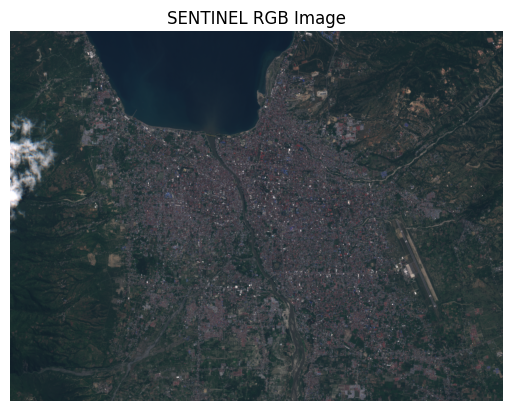

In [115]:
with rasterio.open(path+'pre_sentinel.tif') as src:
    sentinel_image = src.read([1, 2, 3])
    out_transform = src.transform
    image_crs = src.crs
    print(image_crs)

pre_sentinel_image_r = np.dstack([sentinel_image[0], sentinel_image[1], sentinel_image[2]])

plt.imshow(pre_sentinel_image_r/5000)
plt.title('SENTINEL RGB Image')
plt.axis('off')
plt.show()

We have two images and a dataframe:

1. Pre_ event image in EPSG:4326
2. Post_ event image in EPSG 4326
3. Buildings geopandas data frame in EPSG 4326

In this case we don't need to do any CRS conversion but if you tried different image combinations above you likely will have got a different coordinate system at some point. 

As an example, to convert the buildings dataframe to another coordinate system (EPSG:32629) we use the `to_crs` method of the dataframe:

In [116]:
buildings_new_crs = buildings.to_crs("EPSG:32629") 

Checking it as we should **ALWAYS** check everything.

In [117]:
buildings_new_crs.crs

<Projected CRS: EPSG:32629>
Name: WGS 84 / UTM zone 29N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°W and 6°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Côte D'Ivoire (Ivory Coast). Faroe Islands. Guinea. Ireland. Jan Mayen. Liberia, Mali. Mauritania. Morocco. Portugal. Sierra Leone. Spain. United Kingdom (UK). Western Sahara.
- bounds: (-12.01, 0.0, -6.0, 84.01)
Coordinate Operation:
- name: UTM zone 29N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

We can guarantee that our buildings dataframe will be in the same coordinate reference system by saving the CRS of the image to a new variable and always making the transformation, whether they're the same already or not

In [118]:
buildings = buildings.to_crs(image_crs) 

---

Great, we have two images we can use to investigate the damage caused by an earthquake.

For our Machine Learning algorithm we want to provide both an image input and a segmentation map of labelled buildings.

Currently we only have one image and essentially a 'table' (dataframe).

We need to convert our 'buildings_crs' dataframe into an image, which we can do with the `rasterio` package.

First, check the two images are the same size.

In [119]:
print(pre_sentinel_image_r.shape)
print(sentinel_image_r.shape)

# And in only 2D - remember we put our R, G, B images into a stack
print(pre_sentinel_image_r[:,:,0].shape)


(1003, 1337, 3)
(1003, 1337, 3)
(1003, 1337)


When we opened the .tif files we read in a 'transformation', this relates the individual pixels in our image to the coordinate reference frame.

In [120]:
out_transform

Affine(8.983152841195215e-05, 0.0, 119.809926410532,
       0.0, -8.983152841195215e-05, -0.8599572214876179)

Using the `rasterio` package we can convert our dataframe into an image.

Really all this package is doing is gridding a list of points into an image.

![gridding image](gridding.jpg)

---

<div class="alert alert-block alert-success"> 
 <strong>Exercises</strong>
 <br>
 <li> What choices could you make about how to 'grid' data?</li>
</div>

In [121]:
# Rasterize geometries to the shape of the Sentinel image
shapes = ((geom, 255) for geom in buildings.geometry)

out_shape = pre_sentinel_image_r[:,:,0].shape
rasterized_buildings = rasterize(
    shapes=shapes,
    out_shape=out_shape,
    transform=out_transform,
    fill=0,  # Background value
    all_touched=True,  # To mark any pixel touched by the shape
    dtype=rasterio.uint8
)


Plot the image to see what happened

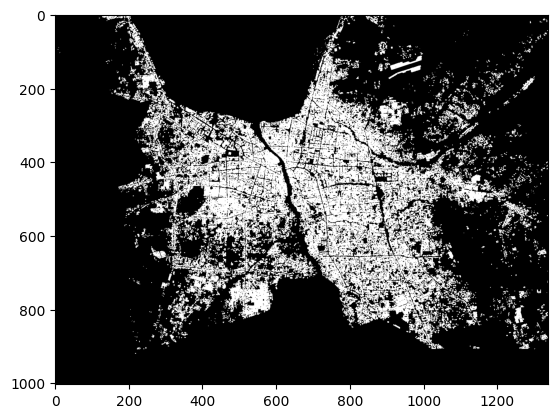

In [122]:
plt.imshow(rasterized_buildings, cmap='gray')
plt.show()

Great! We have an image of buildings which looks vaguely like our satelite imaging.

Let's plot both together to check they're lined up.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0558..2.6978].


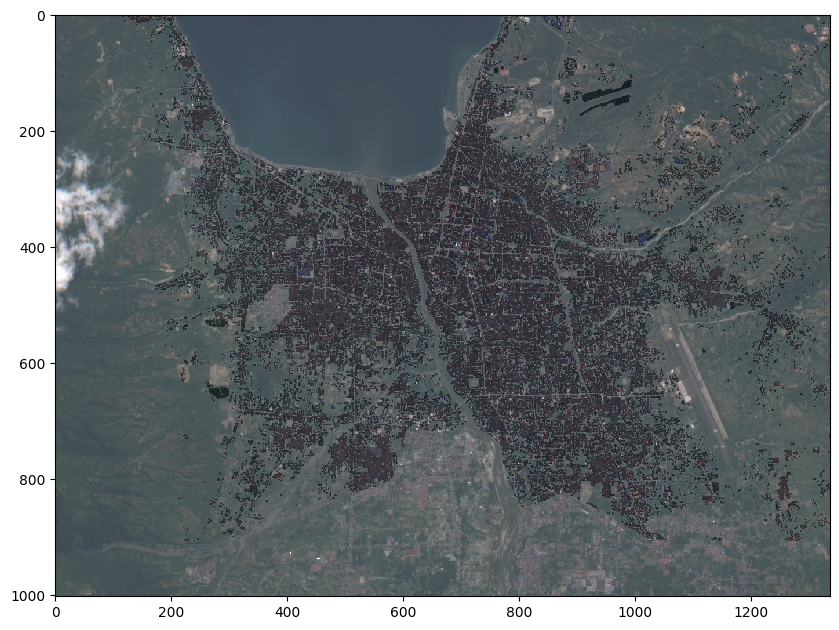

In [123]:
plt.figure(figsize=(10,10))
plt.imshow(pre_sentinel_image_r/5000, cmap='Greys', interpolation='none')
plt.imshow(rasterized_buildings, cmap='Greys', interpolation='none', alpha=0.2)
plt.show()

Let's zoom into smaller region of the images and see if we can see some differences by eye. 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0952..1.1574].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.082..1.1144].


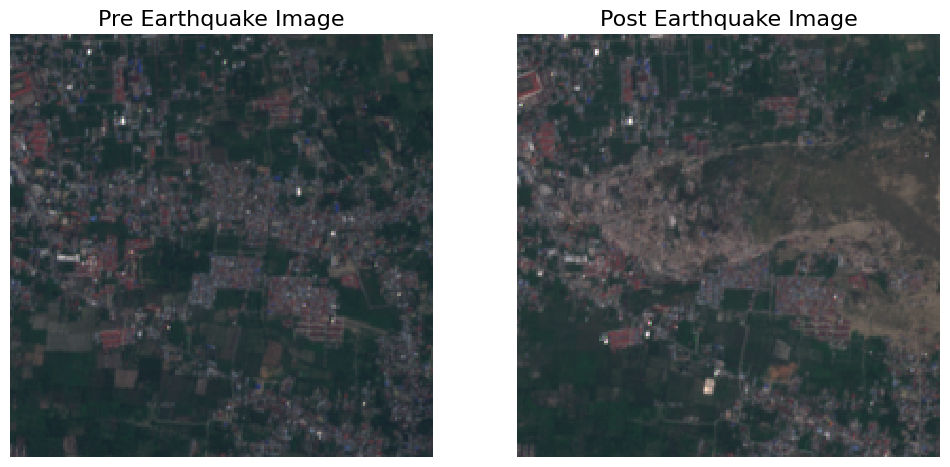

In [124]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
ax2.imshow(sentinel_image_r[800:1000,1000:1200]/5000, interpolation='none')
ax1.imshow(pre_sentinel_image_r[800:1000,1000:1200]/5000, interpolation='none')
ax1.set_title("Pre Earthquake Image", fontsize=16)
ax2.set_title("Post Earthquake Image", fontsize=16)
ax1.set_axis_off()
ax2.set_axis_off()
plt.show()

There is some clear damage. We will use this as a test region.

---

### Now think about how to make the images ML ready.

We need to:

1. Create: Test, Train and, Verify samples
2. Ensure: Labels are between 0-1
3. Augment and normalise the data

We know the image size is 1003, 1337 pixels. We want to break the images up into 'tiles' that are 32 x 32 pixels or 1024 pixels in total.

Sentinel-2 images have a resolution of 10m per pixel so each image is roughly 320m x 320m of land - that should have a good smattering of buildings and land in it.

We have already found a test sample.

To begin, let's define the different test, train and verifying regions of our image.

In [125]:
# Switch to 32 pixels not 20

Testing_image_pre = np.copy(pre_sentinel_image_r[640:960,960:1280,:])
Train_verify_image_pre = np.copy(pre_sentinel_image_r)
Train_verify_image_pre[640:960,960:1280] = 0

The test region size is by definition 320 x 320 pixels so this will give 10 x 10 test images once broken up.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0802..2.6978].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.7788].


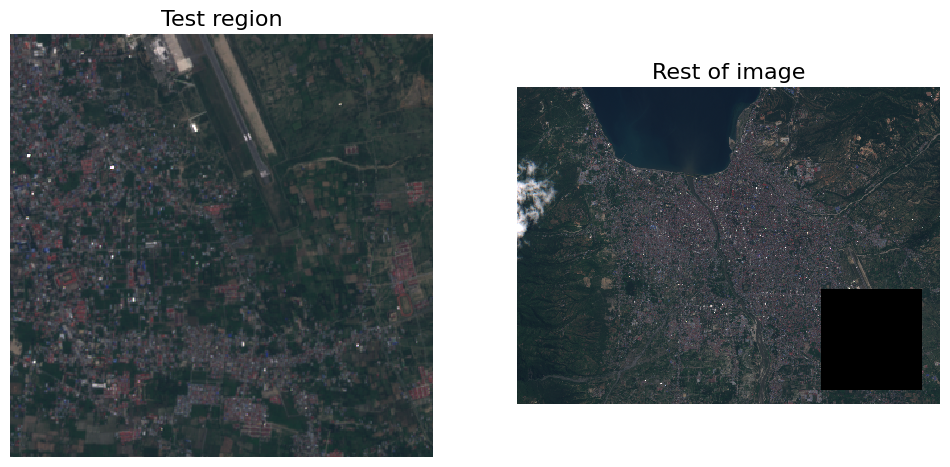

In [126]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
ax1.imshow(Testing_image_pre/5000, interpolation='none')
ax2.imshow(Train_verify_image_pre/5000, interpolation='none')
ax1.set_title("Test region", fontsize=16)
ax2.set_title("Rest of image", fontsize=16)
ax1.set_axis_off()
ax2.set_axis_off()
plt.show()

An few example 20 x 20 images from my test image could be:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1058..2.6978].


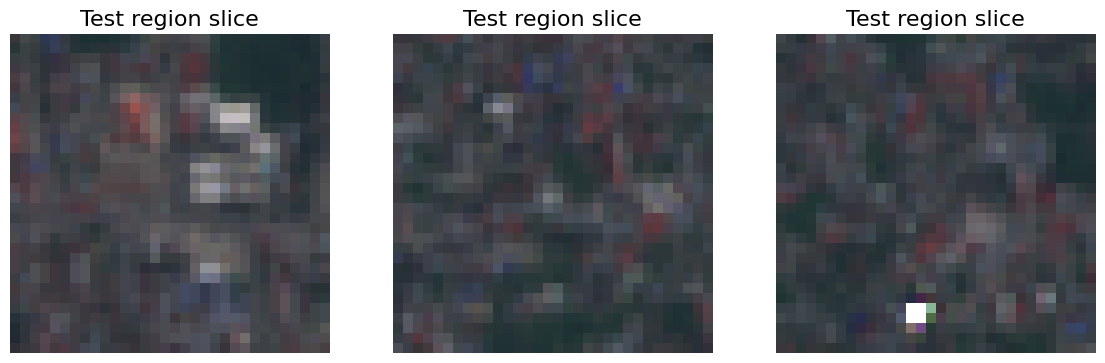

In [127]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 8))
ax1.imshow(Testing_image_pre[0:32,0:32]/5000, interpolation='none')
ax1.set_title("Test region slice", fontsize=16)
ax1.set_axis_off()
ax2.imshow(Testing_image_pre[32:64,0:32]/5000, interpolation='none')
ax2.set_title("Test region slice", fontsize=16)
ax2.set_axis_off()
ax3.imshow(Testing_image_pre[64:96,0:32]/5000, interpolation='none')
ax3.set_title("Test region slice", fontsize=16)
ax3.set_axis_off()
plt.show()

<div class="alert alert-block alert-success"> 
 <strong>Exercises</strong>
 <br>
 <li> Below is a simple `for` loop - can you plot the pictures within this loop?</li>
</div>

In [128]:
array=np.linspace(0,2,3)
print(array)
for i in array:
    print('i = ', i)
    print('i * 32 = ', i * 32)

[0. 1. 2.]
i =  0.0
i * 32 =  0.0
i =  1.0
i * 32 =  32.0
i =  2.0
i * 32 =  64.0


We break up the rest of the image into chunks just like above. Then we save them into a file structure and these files are the ones we would read in.

So that is how we do 1.

1. Train, Verify and Test samples

What about 2 - making sure our labels are between 0 and 1.  Let's define 1 = building from OSM, 0 = other

2. Make sure labels are between 0-1
3. Augment and normalise the data

As a reminder this is our buildings image:

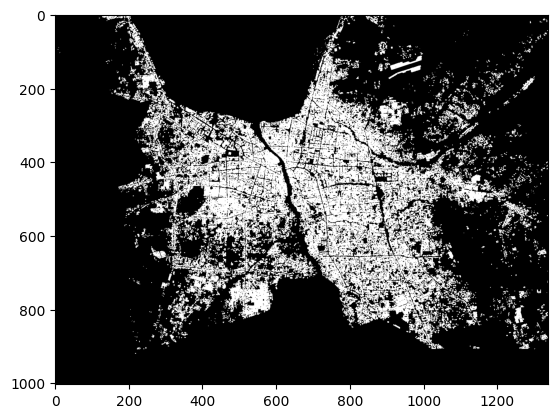

In [129]:
plt.imshow(rasterized_buildings, cmap='gray')
plt.show()

Let's print it and fins out some simple stats about it to understand what the picture shows. 

In [130]:
# first i shall convert it to a numpy array as that is easier to 'do math' on
rb = np.array(rasterized_buildings)
max_image = rb.max()
min_image = rb.min()
print(max_image, min_image)
print('Unique values: ', np.unique(rb))
print(rb.shape)
rb

255 0
Unique values:  [  0 255]
(1003, 1337)


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1003, 1337), dtype=uint8)

So our image goes from 0 to 255.  In this case the only values are 0 and 255. 

So to get it between 0 and 1 we will simple divide by 255!

In [131]:
Labels = rb/255

In [132]:
np.unique(Labels)

array([0., 1.])

And the final part of data preparation is to augment and normalise the data..

1. Train, Verify and Test samples
2. Make sure labels are between 0-1

**3. Augment and normalise the data**

<div class="alert alert-block alert-warning">
See our Data_augmentation.ipynb ntoebook for a refresher on augmentation techniques.
</div>

In [133]:
import torchvision.transforms as transforms

We could do this ourselves easily in numpy but let's use pytorch transforms here anyway...

**Note**
I am currently doing this on the non-normalised buildings images - this si becuse in balck and white they are nice and clear to show you and imshow wants images which are 0-255 to display properly. It would be an easy fix to either * by 255 or change imshow colour scale but this is left for you to play with. 

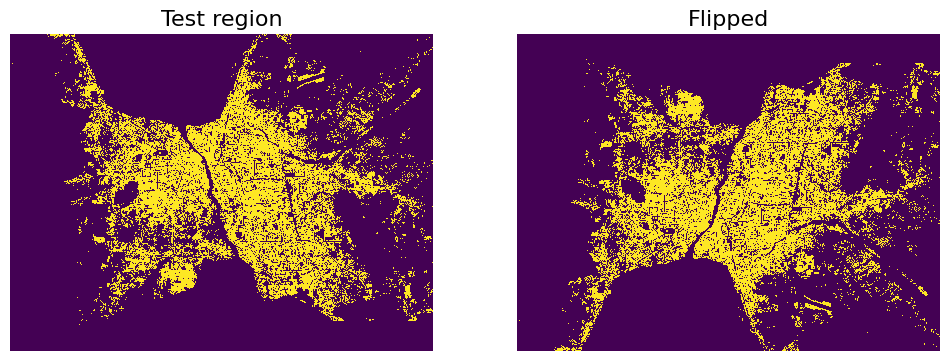

In [134]:
Vertical_Flipping_Transformation = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomVerticalFlip(p=1)
])

new_rb = Vertical_Flipping_Transformation(rb)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
ax1.imshow(rb, interpolation='none')
ax2.imshow(new_rb, interpolation='none')
ax1.set_title("Test region", fontsize=16)
ax2.set_title("Flipped", fontsize=16)
ax1.set_axis_off() # what happens if you set these to on or just comment out these lines?
ax2.set_axis_off()
plt.show()

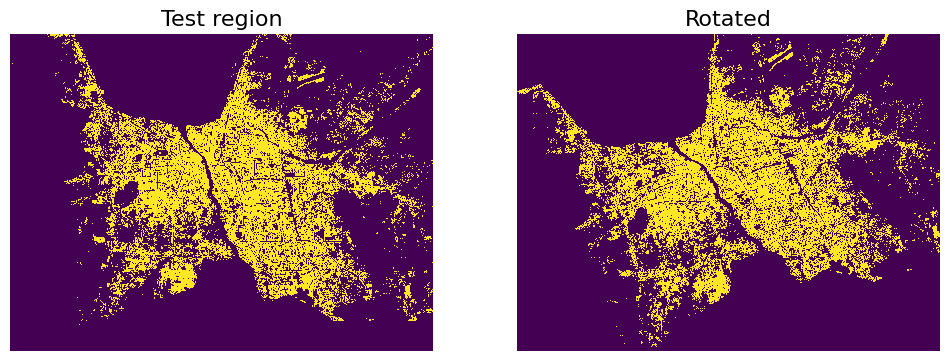

In [135]:
Rotate_Transformation = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=(-66,66))
])

new_rb = Rotate_Transformation(rb)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
ax1.imshow(rb, interpolation='none')
ax2.imshow(new_rb, interpolation='none')
ax1.set_title("Test region", fontsize=16)
ax2.set_title("Rotated", fontsize=16)
ax1.set_axis_off() # what happens if you set these to on or just comment out these lines?
ax2.set_axis_off()
plt.show()

<div class="alert alert-block alert-success"> 
 <strong>Exercises</strong>
 <br>
 <li> Can you now:</li>
 <li> Normalise each band of your data in a simialr way as i normalised the labels set.</li>
 <li> Augment the data as you wish.</li>
 <li> Chunk the data (pre-event image) (and labels!) using a loop and save it into a 'train', 'verify' and 'test' folder.</li>
 <li> We are now ML ready!</li>
 
</div>

---

### Create Dataset

Open the satellite image, split it into 20x20 tiles

In [136]:
pre_earthquake_image = path + 'pre_sentinel.tif'
tile_output_dir = path + 'pre_earthquake_tiles/'
tile_size = 32

os.makedirs(tile_output_dir, exist_ok=True)
tile_information = {}

with rasterio.open(pre_earthquake_image) as src:
    for i in range(0, src.height, tile_size):
        for j in range(0, src.width, tile_size):
            window = Window(j, i, tile_size, tile_size)
            transform = rasterio.windows.transform(window, src.transform)

            data = src.read(window=window)
            if data.shape[0] < 3:
                continue  # Skip non-RGB tiles
            data = data[:3]
            data = np.transpose(data, (1, 2, 0))
            data = (data - data.min()) / (data.max() - data.min() + 1e-5) * 255
            data = data.astype(np.uint8)

            tile_name = f"tile_{i}_{j}.png"
            img = Image.fromarray(data)
            img.save(os.path.join(tile_output_dir, tile_name))

            tile_information[tile_name] = {
                'transform': transform,
                'tile_size': tile_size,
                'i_j': (i, j)
            }

Each tile will then need a binary mask created, this mask gives building pixels a value of 1 (white) and non-building pixels a value of 0 (black).

Because we need to run this for every single time, we package it up into a Python function which can be run with different inputs for each tile and give the output of the binary mask.

In [137]:
def create_binary_mask(tile_transform, tile_size, intersecting_geoms, mask_output_dir, mask_name):
    mask = np.zeros((tile_size, tile_size), dtype=np.uint8)
    if len(intersecting_geoms) > 0:
        shapes = ((geom, 1) for geom in intersecting_geoms)
        mask = rasterize(
            shapes=shapes,
            out_shape=(tile_size, tile_size),
            transform=tile_transform,
            fill=0,
            dtype=np.uint8
        )
    mask_img = Image.fromarray(mask * 255)
    mask_img.save(os.path.join(mask_output_dir, mask_name))
    return mask


Instead of using the geometrical representation of the image (the coordinates) we want to know the pixel representation. This function converts from our CRS to Pixels.

In [138]:
def convert_and_clip_bbox(tile_transform, tile_size, minx, miny, maxx, maxy):
    row_min, col_min = rasterio.transform.rowcol(tile_transform, minx, maxy)
    row_max, col_max = rasterio.transform.rowcol(tile_transform, maxx, miny)

    row_min, row_max = sorted([row_min, row_max])
    col_min, col_max = sorted([col_min, col_max])

    row_min = max(0, row_min)
    col_min = max(0, col_min)
    row_max = min(tile_size, row_max)
    col_max = min(tile_size, col_max)

    if row_max > row_min and col_max > col_min:
        return [col_min, row_min, col_max, row_max]
    return None

Finally, we can combine all of these things to make our datset.

In [139]:
# Inputs
output_dir = path + 'output_annotations/'
mask_dir = path + 'masks/'
annotation_file = os.path.join(output_dir, 'annotations.json')
buildings = gpd.read_file('palu_buildings.geojson')

os.makedirs(output_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

annotations = []
gdf = buildings

for tile_name, info in tile_information.items():
    transform = info['transform']
    tile_size = info['tile_size']
    i, j = info['i_j']
    tile_bounds = rasterio.transform.array_bounds(tile_size, tile_size, transform)
    tile_box = box(*tile_bounds)

    intersecting = gdf[gdf.geometry.intersects(tile_box)]
    boxes, labels, intersecting_geoms = [], [], []

    for _, row in intersecting.iterrows():
        intersection = row.geometry.intersection(tile_box)
        if not intersection.is_empty:
            minx, miny, maxx, maxy = intersection.bounds
            bbox = convert_and_clip_bbox(transform, tile_size, minx, miny, maxx, maxy)
            if bbox:
                boxes.append(bbox)
                labels.append(1)
                intersecting_geoms.append(intersection)

    mask_name = f"mask_{i}_{j}.png"
    if intersecting_geoms:
        create_binary_mask(transform, tile_size, intersecting_geoms, mask_dir, mask_name)

    if boxes:
        annotations.append({
            "tile_path": tile_name,
            "mask_path": mask_name,
            "boxes": [list(map(int, box)) for box in boxes],
            "labels": [int(label) for label in labels]
        })

with open(annotation_file, 'w') as f:
    json.dump(annotations, f, indent=2)

print(f"Created dataset with {len(annotations)} annotated tiles and masks.")


Created dataset with 791 annotated tiles and masks.


---

### Visualise our data before using it

Display some of ours boxes on the satellite image tile

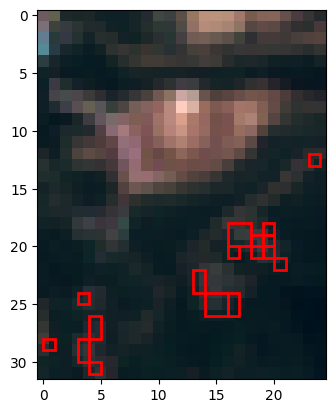

In [140]:
idx = 21 # Change this index to visualize different tiles
annotations = json.load(open(annotation_file, 'r'))
image_path = os.path.join(tile_output_dir + annotations[idx]['tile_path'])
bboxes = annotations[idx]['boxes']

image = Image.open(image_path)
fig, ax = plt.subplots()
ax.imshow(image)

# Draw all bounding boxes on the image
for bbox in bboxes:
    minx, miny, maxx, maxy = bbox

    # Calculate width and height of the bounding box
    width = maxx - minx
    height = maxy - miny

    # Create a rectangle patch for the bounding box
    rect = patches.Rectangle((minx, miny), width, height, linewidth=2, edgecolor='r', facecolor='none')

    # Add the rectangle to the plot
    ax.add_patch(rect)

How many buildings are in the image?

In [141]:
len(annotations[idx]['boxes'])

18

We can also directly plot the masks

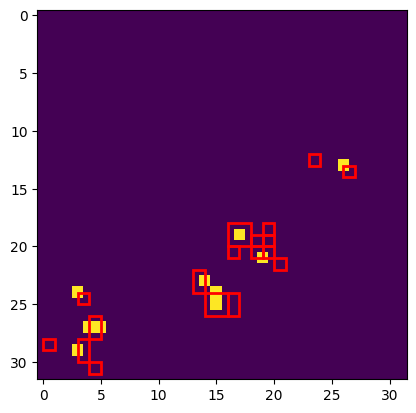

In [142]:
mask_path = os.path.join(mask_dir + annotations[idx]['mask_path'])

image = Image.open(mask_path)
fig, ax = plt.subplots()
ax.imshow(image)

# Draw all bounding boxes on the image
for bbox in bboxes:
    minx, miny, maxx, maxy = bbox

    # Calculate width and height of the bounding box
    width = maxx - minx
    height = maxy - miny

    # Create a rectangle patch for the bounding box
    rect = patches.Rectangle((minx, miny), width, height, linewidth=2, edgecolor='r', facecolor='none')

    # Add the rectangle to the plot
    ax.add_patch(rect)

Now we have a dataset we can use to finetune a ML model in Part 3!